# **Epic Emojis**

<div style="font-size: 14px; color: #6e8192; line-height: 1.5;">
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🎯</span>
    <span>National Student Olympiad Selection for AI</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🧠</span>
    <span>Natural Language Processing</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🏆</span>
    <span>100 points</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🗓️</span>
    <span>May 24, 2025</span>
  </div>
</div>

**Name:** [WRITE YOUR NAME HERE]

**Contestant ID:** [WRITE YOUR CONTESTANT ID HERE]

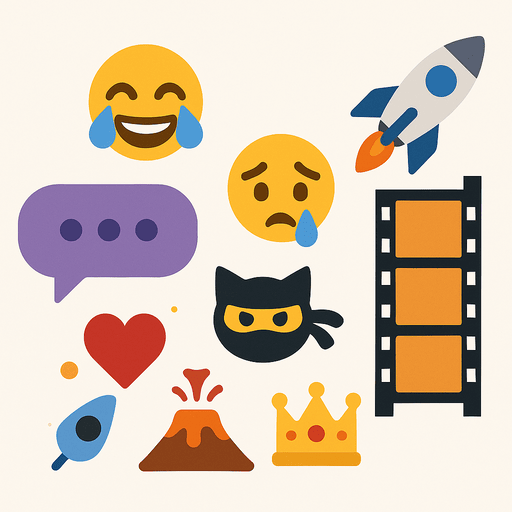

**Emoji Emőke** is a self-proclaimed film critic who is obsessed with both cinema and emojis. She has dedicated her life to summarizing every existing movie title using a single, well-chosen **emoji sequence** (4–5 emojis).
😅 “If a movie can’t be described in three emojis, it’s not even worth watching!”

In this task, you need to train a language model that is capable of generating emoji sequences based on **English movie titles**. You are provided with an existing dataset and a pre-trained model (EmojiLM), which you need to fine-tune and then evaluate.


### **Steps of the Task**

1. **Data loading and exploration** (10 points)

2. **Data cleaning** (5 points)

3. **Model loading** (5 points)

4. **Data preprocessing** (20 points)

5. **Baseline evaluation, untrained model** (10 points)

6. **Model training** (25 points)

7. **Model evaluation and visualization** (3 points)

8. **Results visualization** (7 points)

9. **Attention mechanism visualization** (15 points)

During the solution, you should use NLP and generative language modeling tools to express the meaning behind movie titles using emojis. The final goal is for the model to be able to create **clever emoji montages for new movie titles as well**, just as Emoji Emőke envisioned.


## **Useful Links**

* [Hugging Face Transformers – Documentation](https://huggingface.co/docs/transformers/index)

* [Hugging Face Datasets – Documentation](https://huggingface.co/docs/datasets/index)

* [T5 model – fundamentals](https://arxiv.org/abs/1910.10683)

* [BLEU score – interpretation and example](https://machinelearningmastery.com/calculate-bleu-score-for-text-python/)

* [Python Regex – Filtering Emojis](https://www.regular-expressions.info/unicode.html)


## **Required Imports**

In [ ]:
!pip install --q evaluate nltk
!pip install --q datasets

import torch
import re
import os
import gc
import matplotlib.pyplot as plt
import time
import nltk
from torch.utils.data import DataLoader
from transformers import get_scheduler, DataCollatorForSeq2Seq
from torch.optim import AdamW
from datasets import Dataset
from tqdm import tqdm
from evaluate import load
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')
bleu = load("bleu")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## **Downloading the Dataset**

The downloaded `.csv` file contains the following two columns:

* **title**: an English movie title (e.g., *"Finding Nemo"*, *"The Matrix"*)
* **emojis**: an emoji sequence corresponding to the movie title, which attempts to represent the film’s content, mood, or characters (e.g., `"🐠🔍🌊"` or `"👓💊🤖"`)

You will use this data to train a language model: the goal is for the model to learn to suggest similarly clever emoji sequences for new movie titles.

### **Loading the Dataset**

In [ ]:
import pandas as pd

dataset = pd.read_csv("emoji_dataset.csv")

In [ ]:
dataset.head()

,title,emojis
0,The Shawshank Redemption,NaN
1,The Godfather,👨‍👦🕴️🤵🔫🇮🇹
2,The Dark Knight,🦇🤡🃏🚓🚨
3,The Godfather Part II,🧓👶🔫💼🇮🇹
4,12 Angry Men,👨‍⚖️🔍🤔🔒👥


# **Task 1 (10 points)**

Select **10 random examples** from the dataset and examine what the data looks like.

This step gives us insight into the types of movie titles and their corresponding emojis in the training set. It is worth observing how clear the relationship is between the title and the emoji sequence—for example, whether it reflects the genre, characters, or events.

Also determine how many unique movie titles and how many unique emojis appear in the dataset.

* For movie titles, count the number of unique titles after removing duplicates.
* For emojis, do not count whole emoji sequences; instead, count all individual emoji characters, meaning each distinct emoji is treated as a separate unit.


In [ ]:
# --------- INSERT YOUR SOLUTION HERE --------- (~14–20 lines)

# ----------- END OF YOUR SOLUTION -------------

# **Task 2 (5 points)**

First, clean the dataset:

* Remove rows where either the movie title or the emojis are missing.
* Remove any duplicate rows so that the model does not learn the same information multiple times.

After that, randomly select 60 samples from the cleaned dataset, which will be used to train the model.


In [ ]:
# --------- INSERT YOUR SOLUTION HERE --------- (~3–5 lines)

# ----------- END OF YOUR SOLUTION -------------

<details>
<summary><strong>💥 If Colab warns that GPU memory is full, click here and run this cell!</strong></summary>

This helper function frees up the GPU, deletes unnecessary variables, clears the cache, and attempts to return memory to the system.
❗ **Only use it if the system warns you or you get an error related to memory usage!**

```python
def clear_memory():
    if "inputs" in globals():
        del globals()["inputs"]
    if "model" in globals():
        del globals()["model"]
    if "processor" in globals():
        del globals()["processor"]
    if "trainer" in globals():
        del globals()["trainer"]
    if "peft_model" in globals():
        del globals()["peft_model"]
    if "bnb_config" in globals():
        del globals()["bnb_config"]
    time.sleep(2)
    gc.collect()
    time.sleep(2)
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    time.sleep(2)
    gc.collect()
    time.sleep(2)

    print(f"GPU allocated memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"GPU reserved memory: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

clear_memory()
```

</details>


# **Task 3 (5 points)**

Load the provided pre-trained language model from the Hugging Face Model Hub:
🔗 [`KomeijiForce/t5-base-emojilm`](https://huggingface.co/KomeijiForce/t5-base-emojilm)

This is a T5-based model specifically trained for emoji-based text translation. The model expects inputs to start with the prefix *"translate into emojis:"*, followed by the movie title.

To load the model, you will need the following components:

* **Tokenizer**: processes the input into a format suitable for the model,
* **Generative model**: the trained T5 model that generates emojis.

In [ ]:
# --------- INSERT YOUR SOLUTION HERE --------- (~4–5 lines)

# ----------- END OF YOUR SOLUTION -------------

# **Task 4 (20 points)**

To train the model, the data must be prepared in an appropriate format. You can do this in one of two ways:

* Create a `Dataset` object (e.g., using the Hugging Face `datasets` library), and then implement your own tokenization function that prepares the inputs and labels.
* OR create a `DataLoader`, using a `collate_fn` and helper functions.

**Important technical rules:**

* Inputs must be padded to a uniform length so they can be processed in batches.
* For the output labels, padding tokens must be set to `-100` so that the loss function ignores them.

In [ ]:
# --------- INSERT YOUR SOLUTION HERE --------- (~12–20 lines)

# ----------- END OF YOUR SOLUTION -------------

# **Task 5 (10 points)**

Before training anything, evaluate what the **default, un-fine-tuned model** can do. To do this, you should implement the following:

Write two helper functions:

* The first takes a movie title as input, passes it through the model, and returns the generated emoji sequence.
* The second iterates through the entire training set and compares the true and generated emoji sequences, then computes the BLEU score.

**BLEU** is an automatic evaluation metric commonly used to measure the performance of language models. The higher the score, the better the generated text (in this case, emoji sequences) matches the expected output.


In [ ]:
# --------- INSERT YOUR SOLUTION HERE --------- (~18–25 lines)

# ----------- END OF YOUR SOLUTION -------------

# **Task 6 (25 points)**

In this task, the goal is to fine-tune the EmojiLM model on the selected sample using either your own code or the Hugging Face `Trainer` class.

During training, you must apply **early stopping**, which stops training if performance stops improving.

Since we are working with a small dataset, there is no validation set. Therefore, early stopping must be based on the **training loss**.

### **Two possible approaches:**

* Implement a manual training loop (`train loop`) where you define:

  * the optimizer,
  * learning rate,
  * scheduler,
  * and track the `loss` after each epoch.

* Alternatively, use the Hugging Face `Trainer` class, properly configured (e.g., `EarlyStoppingCallback`, `TrainingArguments`).

### **Saving loss values:**

During training, save the **training loss after each epoch**, so that the learning curve can be visualized later.

---

### **Scoring**

The achievable points depend on the final training loss:

| Training loss achieved | Points awarded |
| ---------------------- | -------------- |
| < 1                    | 25 points      |
| < 2                    | 20 points      |
| < 4                    | 15 points      |
| < 5                    | 10 points      |


In [ ]:
# --------- INSERT YOUR SOLUTION HERE --------- (~25-35 lines)

# ----------- END OF YOUR SOLUTION -------------

# **Task 7 (3 points)**

Now that you have trained the model, let’s see how it performs on specific examples!

Run the model on the first 10 movie titles in the dataset, and print:

* the original movie title,
* the emoji sequence generated by the model,
* and the true (expected) emojis for that example.


In [ ]:
# --------- INSERT YOUR SOLUTION HERE --------- (~5–6 lines)

# ----------- END OF YOUR SOLUTION -------------

# **Task 8 (7 points)**

Now we evaluate how much the model improved after training.

Your tasks:

1. Run the trained model on the first 10 movie titles (as before).

   * Compare the generated emojis with the ground-truth emojis.

2. Create a plot showing the recorded **training loss values per epoch** during training.

3. Compute the **BLEU score** for the trained model as well.

   * Compare this value with the BLEU score of the previously evaluated (untrained) model.


In [ ]:
# --------- INSERT YOUR SOLUTION HERE --------- (~8–15 lines)

# ----------- END OF YOUR SOLUTION -------------

# **Task 9 (15 points)**

After training the T5-based model on the title–emoji pairs, visualize how the attention mechanism works. To do this, select a few examples from the test set and create visualizations showing which parts of the input titles the generated emojis attend to most strongly in the decoder attention layers.

Use heatmap visualizations to represent the encoder–decoder attention weights (cross-attention).

### Requirements:

* Select at least 5 examples from the test set.
* Use attention weights (`cross_attentions`) from the T5 model.
* Create at least 5 heatmaps (e.g., using `matplotlib` or `seaborn`).


In [ ]:
# --------- INSERT YOUR SOLUTION HERE --------- (~15–25 lines)

# ----------- END OF YOUR SOLUTION -------------

---

## 🎉 Congratulations!

You have reached the end of the assignment — excellent work!

---
